The Data Wrangling Workshop: Activity 7.01, page 388
Extracting the top 100 E-books from Gutenberg

Import the necessary libraries, including regex and beautiful soup, Read the HTML from the URL

In [1]:
import urllib.request, urllib.parse, urllib.error
import requests
from bs4 import BeautifulSoup
import ssl
import re

#read in the URL and send to beautiful soup
#Could add a response code to display something if the connection is successful
top100url = 'https://www.gutenberg.org/browse/scores/top'
response = requests.get(top100url)

Write a small function to check the status of the web request

In [6]:
#this checks the status is 200, which is a successful retrieval of the URL
#if the response is anything other than 200, it will print failed, as it was uncessful
def status_check(r):
    if r.status_code==200:
        print("Success!")
        return 1
    else:
        print("Failed!")
        return -1

In [8]:
status_check(response)

Success!


1

Decode the response and pass this on to BeautifulSoup for HTML parsing

In [11]:
#the response.content.decode, decodes the HTML and gives it a specific ending
#the soup gives us the ability to extract

contents = response.content.decode(response.encoding)
soup = BeautifulSoup(contents, 'html.parser')

Find all the href tags and store them in the list of links. Check what the list looks like - print the first 30 elements

In [14]:
#creates an empty list to store all the html data
#finds all the <a> tags and store their href values in the list of links

lst_links=[]
for link in soup.find_all('a'):
    lst_links.append(link.get('href'))

In [16]:
#this will display the first 30 entries into the list link

lst_links[:30]

['/',
 '/donate/',
 '/about/',
 '/about/contact_information.html',
 '/about/background/',
 '/help/mobile.html',
 '/help/',
 '/ebooks/offline_catalogs.html',
 '/donate/',
 '/browse/scores/top',
 '/ebooks/categories',
 '/ebooks/bookshelf/',
 '/ebooks/',
 '/browse/scores/top',
 '/ebooks/categories',
 '/about/pretty-pictures.html',
 '#books-last1',
 '#authors-last1',
 '#books-last7',
 '#authors-last7',
 '#books-last30',
 '#authors-last30',
 '/ebooks/2641',
 '/ebooks/17157',
 '/ebooks/158',
 '/ebooks/2701',
 '/ebooks/1080',
 '/ebooks/9070',
 '/ebooks/3186',
 '/ebooks/10554']

Use a regular expression to find the numeric digits in these links. These are the file numbers for the top 100 eBooks

In [19]:
#creates another new empty list for the bok number

booknum=[]

In [21]:
#this will get a list of the top 100 books
#the loop extracts book numbers from the list links, by finding numeric substrings 

for i in range(19,119):
    link=lst_links[i]
    link=link.strip()
    n=re.findall('[0-9]+',link)
    if len(n)==1:
        booknum.append(int(n[0]))

In [23]:
#print what is found in the above lists
print ("\nThe file numbers for the top 100 ebooks on Gutenberg are shown below\n"+"-"*70)
print(booknum)


The file numbers for the top 100 ebooks on Gutenberg are shown below
----------------------------------------------------------------------
[7, 30, 30, 2641, 17157, 158, 2701, 1080, 9070, 3186, 10554, 100, 84, 580, 16389, 289, 2160, 394, 6593, 1513, 18857, 13415, 5225, 3011, 31516, 8525, 24151, 4352, 2554, 174, 11, 145, 308, 37106, 164, 24571, 1342, 2542, 73144, 383, 2643, 215, 1250, 67979, 14323, 3189, 21279, 6761, 64820, 29418, 74, 7241, 4085, 1259, 345, 236, 25305, 50290, 17489, 9830, 41445, 43789, 2638, 57333, 766, 521, 108, 35, 27761, 61963, 209, 27673, 24022, 20228, 86, 69087, 103, 2527, 2147, 599, 2097, 1695, 1874, 62, 1837, 4081, 47, 42324, 1079, 902, 10623, 2911, 7700, 7178, 16433, 82, 19591, 121, 10947, 1051]


Initialize the empty list to hold the file numbers over an appropriate range and use regex to find the numeric digits in the link href strong. Use findall

What does the soup object's text look like? Use the .text method and print only the first 2,000 characters

In [27]:
#this prints the first 2000 characters

print(soup.text[:2000])





Top 100 | Project Gutenberg





































X

Go!







 Donate 





About▼

About Project Gutenberg 
Contact Us
History & Philosophy
Kindle & eReaders
Help Pages
Offline Catalogs
Donate



Frequently Downloaded
Main Categories
Reading Lists
Search Options



Frequently Downloaded
Main Categories



Frequently Viewed or Downloaded
These listings are based on the number of times each eBook gets downloaded.
      Multiple downloads from the same Internet address on the same day count as one download, and addresses that download more than 100 eBooks in a day are considered robots and are not counted.

Downloaded Books
2025-07-211151664
last 7 days7432111
last 30 days33772725

Pretty Pictures


Top 100 EBooks yesterday
Top 100 Authors yesterday
Top 100 EBooks last 7 days
Top 100 Authors last 7 days
Top 100 EBooks last 30 days
Top 100 Authors last 30 days


Top 100 EBooks yesterday

A Room with a View by E. M.  Forster (4604)
Gulliver's Travels into Several Remot

Search in the extracted text (using a regular expression) from the soup object to find the names of the top 100 eBooks (yesterdays ranking).

In [30]:
#this is a temp list, but it is a new blank list

lst_titles_temp=[]

Create a starting index. It should point at the text Top 100 Ebooks yesterday. Use tge splitlines method of soup.text. It splits the lines of text of the soup object

In [33]:
#splits all text into a list of lines
#locates the first line that matches 'Top 100 EBooks yesterday'

start_idx=soup.text.splitlines().index('Top 100 EBooks yesterday')

Run the for loop 1-100 and add the strings of the next 100 linnes to this temporary list

In [36]:
#splitlines() splits the text into a bunch of lines

for i in range(100):
    lst_titles_temp.append(soup.text.splitlines()[start_idx+2+i])

Use a regular expression to extract only text from the name strings and append it into an empty list. Use match and span to find the indicies and use them.Print the list of titles

In [39]:
#re.match('^[a-zA-Z ]*', lst_titles_temp[i]) finds the span of characters at the start of the string that are letters or spaces.
#.span() returns a tuple (start, end) for the match.
#lst_titles_temp[i][id1:id2] slices out just those characters.
# group() also could have been used in the code
lst_titles=[]
for i in range(100):
    id1,id2=re.match('^[a-zA-Z ]*',lst_titles_temp[i]).span()
    lst_titles.append(lst_titles_temp[i][id1:id2])

In [41]:
#the code iterates through all the 1st titles and prints them

for l in lst_titles:
    print(l)

Top 
Top 
Top 
Top 


Top 

A Room with a View by E
Gulliver
Emma by Jane Austen 
Moby Dick
A Modest Proposal by Jonathan Swift 
The Imaginary Invalid by Moli
The Mysterious Stranger
Right Ho
The Complete Works of William Shakespeare by William Shakespeare 
Frankenstein
The Pickwick Papers by Charles Dickens 
The Enchanted April by Elizabeth Von Arnim 
The Wind in the Willows by Kenneth Grahame 
The Expedition of Humphry Clinker by T
Cranford by Elizabeth Cleghorn Gaskell 
History of Tom Jones
Romeo and Juliet by William Shakespeare 
A Journey to the Centre of the Earth by Jules Verne 
The Lady with the Dog and Other Stories by Anton Pavlovich Chekhov 
The Satyricon 
The Lady of the Lake by Walter Scott 
The Eyes Have It by Philip K
Eve
The Sky Trap by Frank Belknap Long 
Laughter
Crime and Punishment by Fyodor Dostoyevsky 
The Picture of Dorian Gray by Oscar Wilde 
Alice
Middlemarch by George Eliot 
Three men in a boat 
Little Women
Twenty Thousand Leagues under the Sea by Jules Verne

The Data Wrangling Workshop: Activity 7.02, page 390
Building your own movie database by reading an API. 
http://www.omdbapi.com/?

Import urllib.request, urllib.parse, urllib.error, and json

In [1]:
#importing new libraries
import urllib.request, urllib.parse, urllib.error
import json

Load the secret API key from a JSON file, stored in the same folder, in a variable - JSON.loands()

Obtain a key and store it in a JSON file as APIkeys.json
Open the APIkeys.json file

In [11]:
#had to create a file that holds the API key as a raw json file

with open('APIkeys.json', 'w') as f:
    f.write('{\n    "OMDBapi": "bdcd3485"\n}')

In [13]:
#this opens the json file, reads it, and gets the key associated with omdbapi

with open('APIkeys.json') as f:
    keys = json.load(f)
    omdbapi = keys['OMDBapi']

In [17]:
print(keys)

{'OMDBapi': 'bdcd3485'}


Assign the OMDB portal, as a string to a variable

In [21]:
#a great reason to set it this way, is if the URL changes, it is an easy modification
#changing the URL is much easier than changing multiple lines of code.

serviceurl = 'http://www.omdbapi.com/?'

Create a variable called apikey with the last portion of the URL

In [23]:
#turns the api key into a string that is part of the api request

apikey = '&apikey='+omdbapi

Write a utility function called print_json, to print the movie data from a JSON file

In [27]:
#This will print select fields from the API, it is the dictionary for printing
#list_keys defines what to print, assuming they exist, from the API
#it will print dashes as well before and after the return, so it is easier to separate

def print_json(json_data):
    list_keys=['Title', 'Year', 'Rated', 'Released', 'Runtime', 'Genre', 'Director', 'Writer', 
               'Actors', 'Plot', 'Language', 'Country', 'Awards', 'Ratings', 
               'Metascore', 'imdbRating', 'imdbVotes', 'imdbID']
    print("-"*50)
    for k in list_keys:
        if k in list(json_data.keys()):
            print(f"{k}: {json_data[k]}")
    print("-"*50)

Write a utility function to download a poster of the movie based on the information from the JSON data set and save it on your local folder. 

In [29]:
#this takes our library, and imports the title and poster, it will bring in the title of the movie and the image of the poster
#it splits the poster url by a '.' 
#grabs the poster image, and saves it as a raw image
#if a posters dictionary does not exist, it creates one. 
#saves the file, with the extention (png, jpg)
#this will download the movie poster images

def save_poster(json_data):
    import os
    title = json_data['Title']
    poster_url = json_data['Poster']
    poster_file_extension=poster_url.split('.')[-1]
    poster_data = urllib.request.urlopen(poster_url).read()
        
    savelocation=os.getcwd()+'\\'+'Posters'+'\\'
    if not os.path.isdir(savelocation):
        os.mkdir(savelocation)
    
    filename=savelocation+str(title)+'.'+poster_file_extension
    f=open(filename,'wb')
    f.write(poster_data)
    f.close()

In [31]:
#attaches the API key to the end of the API URL
#prints what title is being retrieved along with the url
#the last 3 lines are requesting the API

#the second part is if the call is successful it will print the formatted data
#If it is unsuccessful it will print an error and give a reason as to why
#it will aslo save the movie poster

def search_movie(title):
    try:
        url = serviceurl + urllib.parse.urlencode({'t': str(title)})+apikey
        print(f'Retrieving the data of "{title}" now... ')
        print(url)
        uh = urllib.request.urlopen(url)
        data = uh.read()
        json_data=json.loads(data)
        
        if json_data['Response']=='True':
            print_json(json_data)
            if json_data['Poster']!='N/A':
                save_poster(json_data)
        else:
            print("Error encountered: ",json_data['Error'])
    
    except urllib.error.URLError as e:
        print(f"ERROR: {e.reason}")

In [33]:
#searches a valid movie title as a positive test
search_movie("Titanic")

Retrieving the data of "Titanic" now... 
http://www.omdbapi.com/?t=Titanic&apikey=bdcd3485
--------------------------------------------------
Title: Titanic
Year: 1997
Rated: PG-13
Released: 19 Dec 1997
Runtime: 194 min
Genre: Drama, Romance
Director: James Cameron
Writer: James Cameron
Actors: Leonardo DiCaprio, Kate Winslet, Billy Zane
Plot: A seventeen-year-old aristocrat falls in love with a kind but poor artist aboard the luxurious, ill-fated R.M.S. Titanic.
Language: English, Swedish, Italian, French
Country: United States
Awards: Won 11 Oscars. 126 wins & 83 nominations total
Ratings: [{'Source': 'Internet Movie Database', 'Value': '7.9/10'}, {'Source': 'Rotten Tomatoes', 'Value': '88%'}, {'Source': 'Metacritic', 'Value': '75/100'}]
Metascore: 75
imdbRating: 7.9
imdbVotes: 1,348,847
imdbID: tt0120338
--------------------------------------------------


In [35]:
#this shows the error that happens, to ensure the code returns an error properly
#positive testing
search_movie("Random_error")

Retrieving the data of "Random_error" now... 
http://www.omdbapi.com/?t=Random_error&apikey=bdcd3485
Error encountered:  Movie not found!


Connect to an API of your choice and do a simple data pull - you can use any API - except the API you have selected for your project.

In previous versions of this course we have always used Twitter, but with recent organizational changes at Twitter, it has become increasingly difficult to access the free APIs available at Twitter. You are more than welcome to try to use Twitter's API for this portion of the assignment, but please note, there has been some inconsistency experienced when following along with their documentation posted.

In [41]:
#using weather.gov, required lat and lon, or a second API to leverage Zip

import urllib.request
import json

#coordinates of Bellevue NE
lat = 41.0931
lon = -95.5603

Connect to the API and do a "Get" call/operation on the API to return a subset of data from the API

In [43]:
#get the forcast with the lat and lon - using the coordinates above
points_url = f"https://api.weather.gov/points/{lat},{lon}"

In [45]:
with urllib.request.urlopen(points_url) as response:
    points_data = json.load(response)

forecast_url = points_data['properties']['forecast']

In [47]:
#get the forecast, and load the response
with urllib.request.urlopen(forecast_url) as response:
    forecast_data = json.load(response)

In [49]:
#print the forecast
#fun fact, corn sweat is a real thing here in NE! This tracks with the Extreme Heat Warning we are under

periods = forecast_data['properties']['periods']
for period in periods[:3]:  # Print the next 3 forecast periods
    print(f"{period['name']}: {period['detailedForecast']}")

Today: Sunny, with a high near 94. Heat index values as high as 110. South southeast wind 8 to 13 mph, with gusts as high as 18 mph.
Tonight: Mostly clear. Low around 75, with temperatures rising to around 77 overnight. Heat index values as high as 109. South wind 8 to 13 mph.
Monday: Sunny, with a high near 95. Heat index values as high as 109. South wind 7 to 10 mph.


Using one of the datasets provided in Weeks 5 & 6, or a dataset of your own, choose 3 of the following visualizations to complete. You must submit via PDF along with your code. You are free to use Matplotlib, Seaborn or another package if you prefer.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("C:\\Users\\hessk\\OneDrive\\Desktop\\DSC540\\candyhierarchy2017.csv", encoding="latin1")

In [57]:
#candy columns are in Q6, so selecting only the candy columns
candy_cols = [col for col in df.columns if col.startswith('Q6 |')]

print(candy_cols)

['Q6 | 100 Grand Bar', 'Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes)', 'Q6 | Any full-sized candy bar', 'Q6 | Black Jacks', 'Q6 | Bonkers (the candy)', 'Q6 | Bonkers (the board game)', 'Q6 | Bottle Caps', "Q6 | Box'o'Raisins", 'Q6 | Broken glow stick', 'Q6 | Butterfinger', 'Q6 | Cadbury Creme Eggs', 'Q6 | Candy Corn', 'Q6 | Candy that is clearly just the stuff given out for free at restaurants', 'Q6 | Caramellos', 'Q6 | Cash, or other forms of legal tender', 'Q6 | Chardonnay', 'Q6 | Chick-o-Sticks (we donÕt know what that is)', 'Q6 | Chiclets', 'Q6 | Coffee Crisp', 'Q6 | Creepy Religious comics/Chick Tracts', 'Q6 | Dental paraphenalia', 'Q6 | Dots', 'Q6 | Dove Bars', 'Q6 | Fuzzy Peaches', 'Q6 | Generic Brand Acetaminophen', 'Q6 | Glow sticks', 'Q6 | Goo Goo Clusters', "Q6 | Good N' Plenty", 'Q6 | Gum from baseball cards', 'Q6 | Gummy Bears straight up', 'Q6 | Hard Candy', 'Q6 | Healthy Fruit', 'Q6 | Heath Bar', "Q6 | Hershey's Dark Chocolate", 

In [59]:
#count the number of joy in each
joy_counts = {}
for candy in candy_cols:
    joy_counts[candy[5:]] = (df[candy] == 'JOY').sum()

In [61]:
#Find the top 10 candies
top_joy = pd.Series(joy_counts).sort_values(ascending=False).head(10)

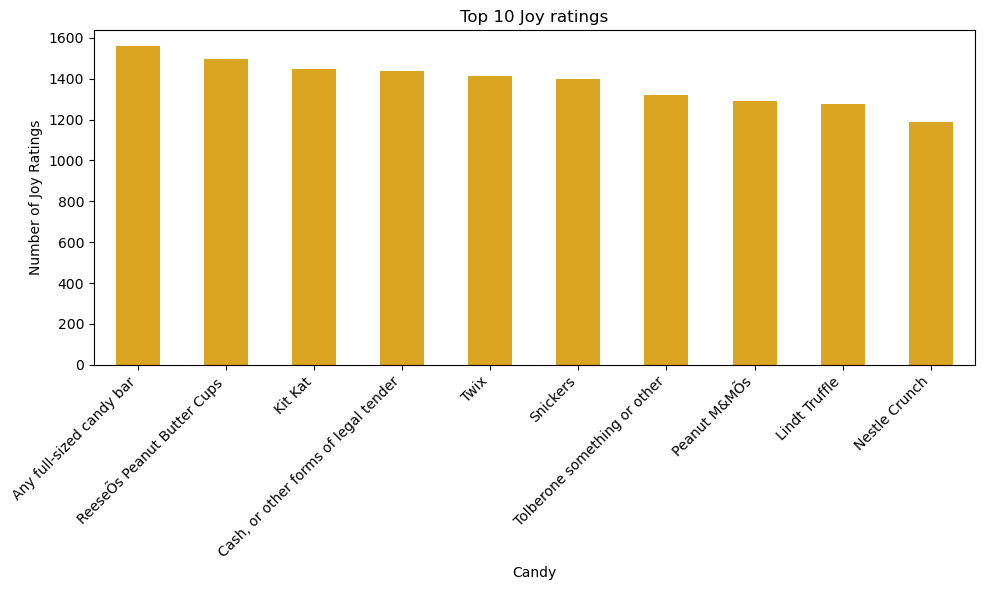

In [63]:
plt.figure(figsize=(10,6))
top_joy.plot(kind='bar', color='goldenrod')
plt.title('Top 10 Joy ratings')
plt.ylabel('Number of Joy Ratings')
plt.xlabel('Candy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top10_joy_candies.png')
plt.show()

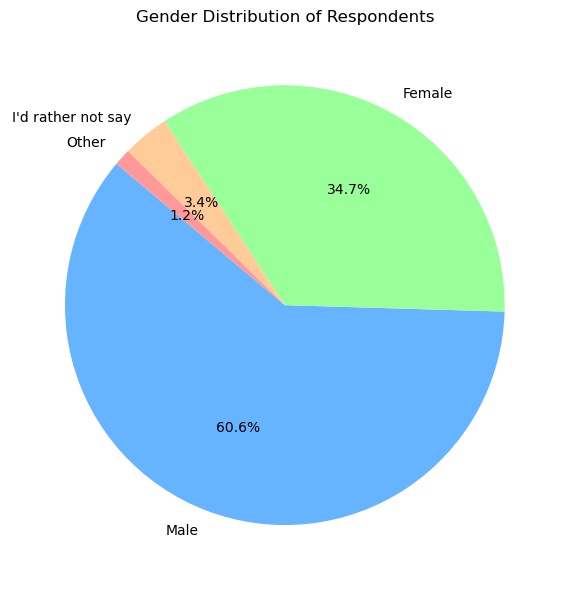

In [65]:
#print a pie chart based on gender 
#gender was listed under Q2

gender_counts = df['Q2: GENDER'].value_counts().dropna()
plt.figure(figsize=(6,6))
gender_counts.plot.pie(autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99','#ffcc99','#ff9999'])
plt.title('Gender Distribution of Respondents')
plt.ylabel('')
plt.tight_layout()
plt.savefig('gender_distribution.png')
plt.show()

In [69]:
#age is Q3, convert all to numeric
df['Q3: AGE'] = pd.to_numeric(df['Q3: AGE'], errors='coerce')

#drop any missing ages
ages = df['Q3: AGE'].dropna()

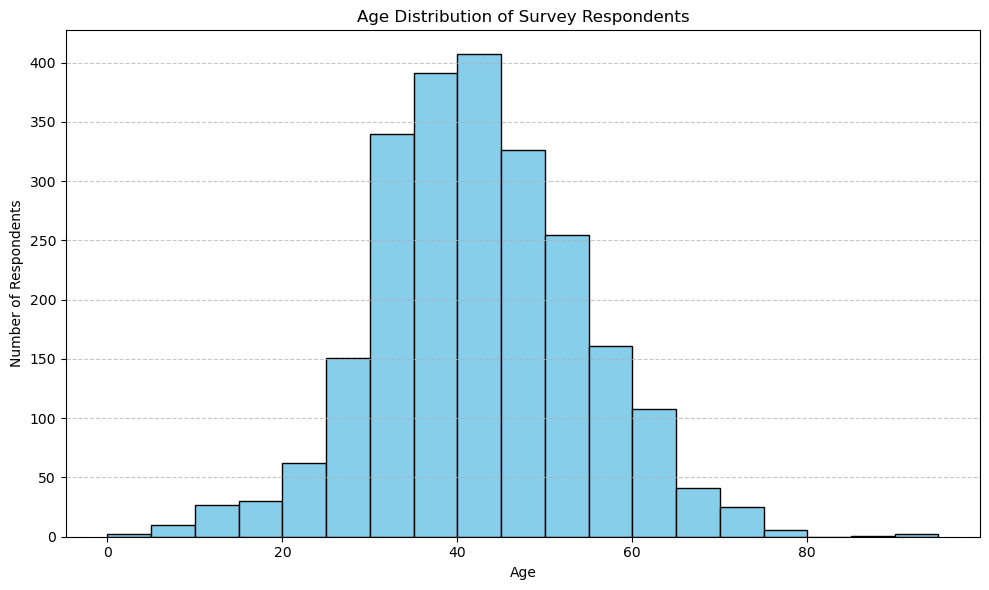

In [71]:
#histogram
plt.figure(figsize=(10,6))
plt.hist(ages, bins=range(0, 100, 5), color='skyblue', edgecolor='black')
plt.title('Age Distribution of Survey Respondents')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('age_distribution_chart.png')
plt.show()